# Outliers

### 1. What is an Outlier?
An outlier is an observation in a given dataset that lies far away from the rest of the observations.
If outliers are not treated before Exploratory Data Analysis, then we might get bias in our analysis.

### 2. Reasons an outlier exists in Dataset: 
1. Data Entry Error
2. Variability in the dataset

#### Everytime outliers are not dangerous
-- Keeping or not keeping outliers depends on the problem statement.

### 3. How to treat an outlier? 
1. Trimming
2. Capping

### 4. Various ways to find an outlier:
1. z-score: When distribution follows normal distribution (bell-shaped curve)
2. interquartile range - When distribution is skewed distribution
3. percentiles - When distributions is neither normal nor skewed

## Outlier removal using z-score

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
data = pd.read_csv("scholarship.csv")

In [3]:
df = data.copy()

In [4]:
df.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


In [5]:
df.shape

(1000, 3)

C:\Users\HP\AppData\Local\Temp\ipykernel_3464\415168773.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["semester_percentage"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3464\415168773.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["scholarship_exam_marks"])


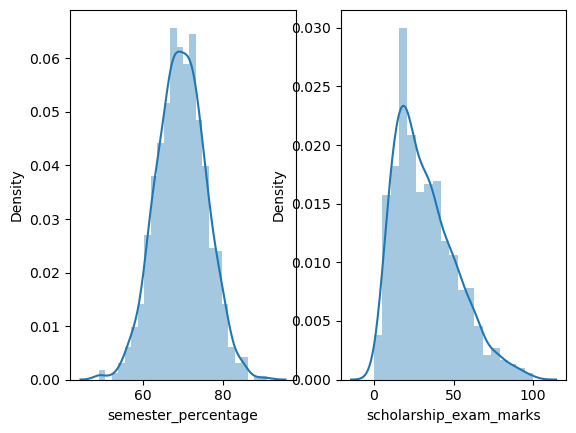

In [11]:
plt.subplot(1,2,1)
sns.distplot(df["semester_percentage"])

plt.subplot(1,2,2)
sns.distplot(df["scholarship_exam_marks"])

plt.show()

In [12]:
# semester_percentage is a normal distribution curve

mean = df["semester_percentage"].mean()
std = df["semester_percentage"].std()

print(mean, ",", std)

69.6124 , 6.158978751323897


In [16]:
# Outlier values 
df[(df["semester_percentage"] > Highest_Allowed) | (df["semester_percentage"] < Lowest_Allowed)]

,semester_percentage,scholarship_exam_marks,got_scholarship
485,49.2,44,1
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
999,49.0,10,1


#### If we have less number of rows, then apply Trimming else apply Capping!

### Trimming

In [15]:
Highest_Allowed = mean + 3*std
Lowest_Allowed = mean - 3*std
## Values > Highest_Allowed and < Lowest_Allowed are considered outliers
print(Lowest_Allowed, ",", Highest_Allowed)

51.13546374602831 , 88.08933625397168


In [33]:
df[(df["semester_percentage"] < Highest_Allowed) & (df["semester_percentage"] > Lowest_Allowed)] 
# This is dataset after removing outliers. This method is called Trimming

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
991,70.4,57,0,0.127878
992,62.6,12,0,-1.138565
993,67.3,21,1,-0.375452
994,64.8,63,0,-0.781363


#### How to use z-score to remove outliers?


In [20]:
df["z_score"] = (df["semester_percentage"] - df["semester_percentage"].mean())/(df["semester_percentage"].std())

In [21]:
df.head()

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371


In [23]:
df[(df["z_score"] < -3) | (df["z_score"] > 3)] ## These values are outliers

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


In [24]:
df[(df["z_score"] > -3) & (df["z_score"] < 3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
991,70.4,57,0,0.127878
992,62.6,12,0,-1.138565
993,67.3,21,1,-0.375452
994,64.8,63,0,-0.781363


### Capping

In [25]:
Upper_limit = mean + 3*std
Lower_limit = mean - 3*std

In [26]:
df["semester_percentage"] = np.where(df["semester_percentage"]>Upper_limit, Upper_limit, np.where(df["semester_percentage"] < Lower_limit, Lower_limit, df["semester_percentage"]))

In [30]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
0,71.900000,26,1,0.371425
1,74.600000,38,1,0.809810
2,75.400000,40,1,0.939701
3,64.200000,8,1,-0.878782
4,72.300000,17,0,0.436371
...,...,...,...,...
995,88.089336,44,1,3.099150
996,88.089336,65,1,3.505062
997,51.135464,34,0,-3.362960
998,86.200000,46,1,2.693239


In [29]:
df[(df["semester_percentage"]<Lower_limit) & (df["semester_percentage"]>Upper_limit)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score


## Outlier Removal using Interquartile Range

<Axes: ylabel='scholarship_exam_marks'>

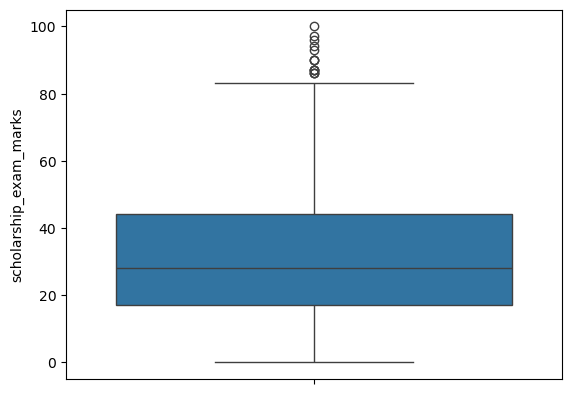

In [34]:
# scholarship_exam_marks is skewed distribution
sns.boxplot(df["scholarship_exam_marks"])

# Blue box is the IQR, below line is Q1 and minimum value and above line is max value, values above maximum value are outliers

#### How to find Quartiles?

In [36]:
Q1 = df["scholarship_exam_marks"].quantile(0.25)
Q3 = df["scholarship_exam_marks"].quantile(0.75)
IQR = Q3-Q1
print(Q1, ",", Q3, ",", IQR)

17.0 , 44.0 , 27.0


In [37]:
df.describe()
# 25% is Q1, 50% is Q2 and 75% is Q3

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,69.614985,32.225000,0.489000,9.876544e-16
std,6.126884,19.130822,0.500129,1.000000e+00
min,51.135464,0.000000,0.000000,-3.362960e+00
25%,65.500000,17.000000,0.000000,-6.677081e-01
50%,69.600000,28.000000,0.000000,-2.013321e-03
75%,73.700000,44.000000,1.000000,6.636815e-01
max,88.089336,100.000000,1.000000,3.505062e+00


In [38]:
min_value = Q1 - 1.5*IQR
max_value = Q3 + 1.5*IQR
print(min_value, ",", max_value)

-23.5 , 84.5


#### Find outliers using IQR

In [39]:
df[(df["scholarship_exam_marks"]< min_value) | (df["scholarship_exam_marks"] > max_value)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z_score
9,77.5,94,1,1.280667
40,66.0,86,1,-0.586526
61,75.1,86,0,0.890992
134,63.3,93,0,-1.024910
162,78.0,90,0,1.361849
283,70.9,87,0,0.209061
290,83.8,87,0,2.303564
311,69.7,87,1,0.014223
324,66.4,90,0,-0.521580
630,65.6,96,1,-0.651472


#### How to remove these outliers? 

### Trimming

In [41]:
new_data = df[(df["scholarship_exam_marks"]> min_value) & (df["scholarship_exam_marks"] < max_value)]

C:\Users\HP\AppData\Local\Temp\ipykernel_3464\464207712.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["scholarship_exam_marks"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3464\464207712.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_data["scholarship_exam_marks"])


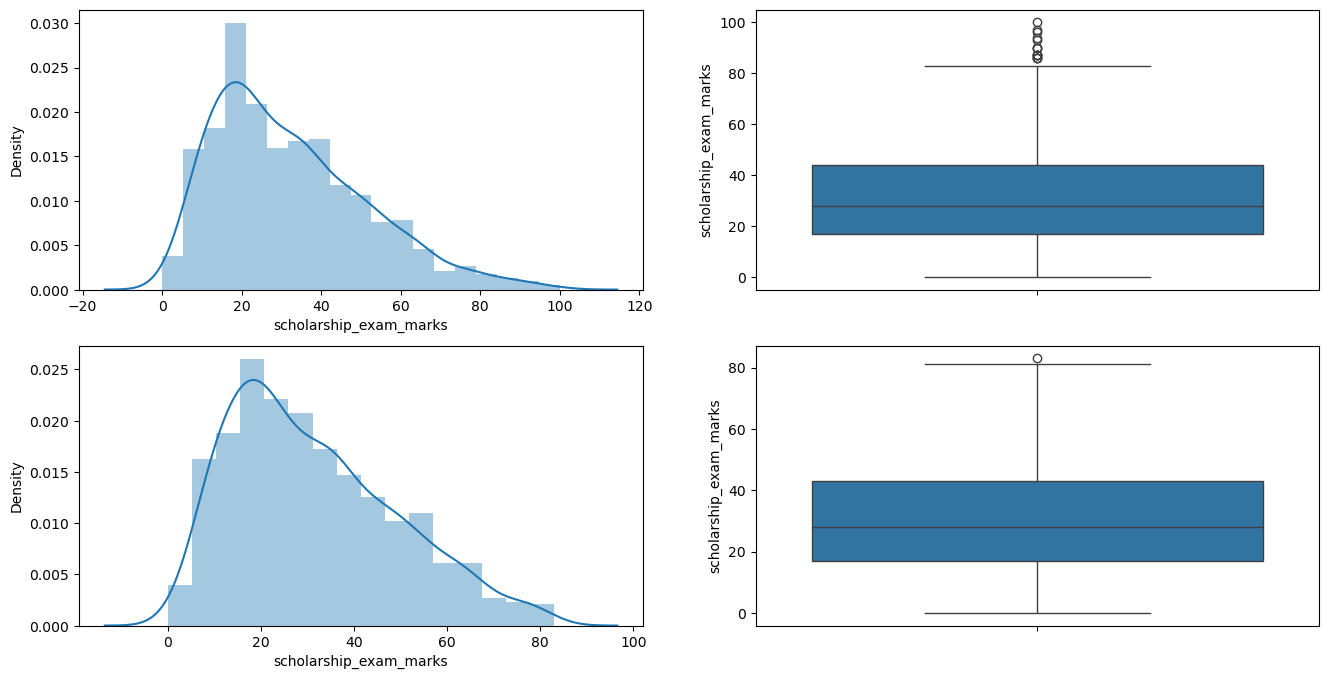

In [44]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df["scholarship_exam_marks"])

plt.subplot(2,2,2)
sns.boxplot(df["scholarship_exam_marks"])

plt.subplot(2,2,3)
sns.distplot(new_data["scholarship_exam_marks"])

plt.subplot(2,2,4)
sns.boxplot(new_data["scholarship_exam_marks"])
plt.show()

### Capping 

In [45]:
df["scholarship_exam_marks"] = np.where(df["scholarship_exam_marks"]>max_value, max_value, np.where(df["scholarship_exam_marks"] < min_value, min_value, df["scholarship_exam_marks"]))

<Axes: ylabel='scholarship_exam_marks'>

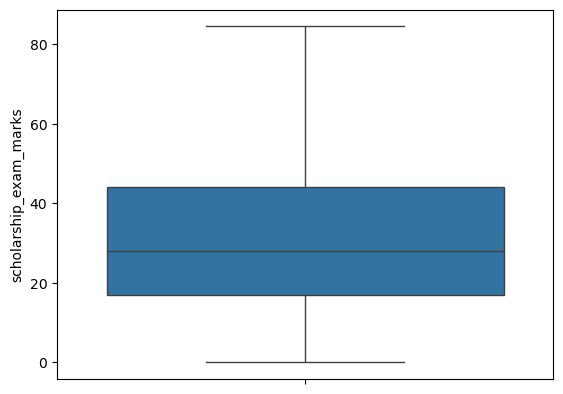

In [47]:
sns.boxplot(df["scholarship_exam_marks"])

## Outlier Removal using Percentile

In [48]:
data_set = pd.read_csv("weight-height.csv")

In [49]:
data_set.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


C:\Users\HP\AppData\Local\Temp\ipykernel_3464\46069716.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_set["Height"])


<Axes: xlabel='Height', ylabel='Density'>

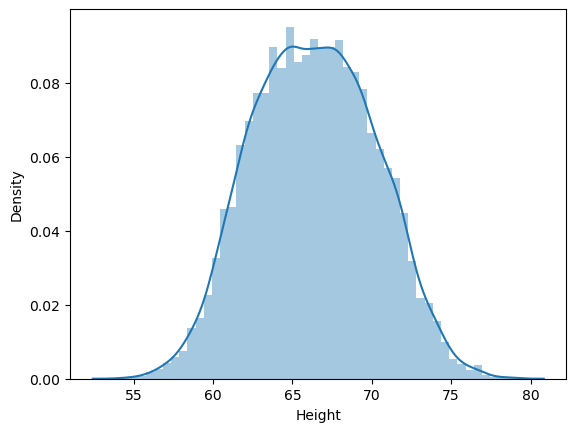

In [50]:
sns.distplot(data_set["Height"]) #Not exactly a normal distribution

<Axes: ylabel='Height'>

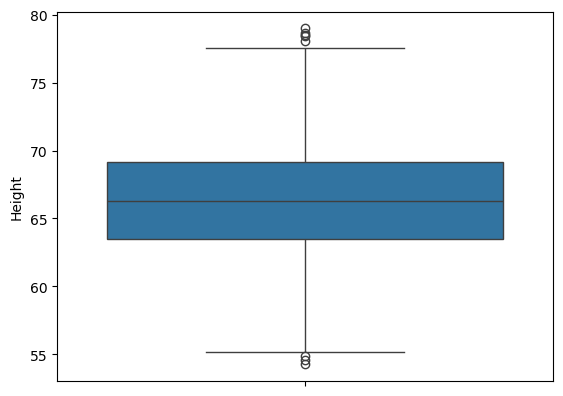

In [51]:
sns.boxplot(data_set["Height"])

In [55]:
min_limit = data_set["Height"].quantile(0.01)
max_limit = data_set["Height"].quantile(0.99)

print(max_limit, ",", min_limit)
# Data less than min_limit and greater than max_limit are considered outliers

74.7857900583366 , 58.13441158671655


In [56]:
data_set[(data_set["Height"] < min_limit) | (data_set["Height"] > max_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


### Trimming

In [57]:
new_data_set = data_set[(data_set["Height"] > min_limit) & (data_set["Height"] < max_limit)]

<Axes: ylabel='Height'>

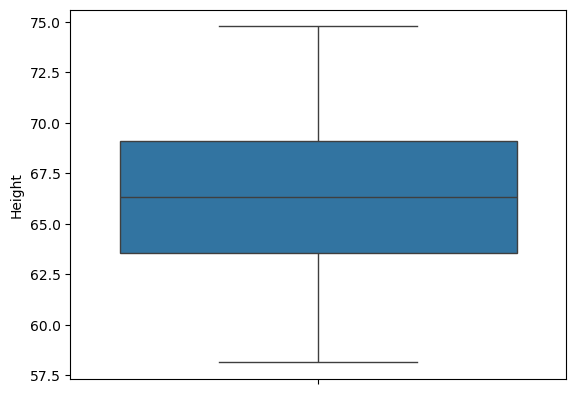

In [58]:
sns.boxplot(new_data_set["Height"])

### Capping

In [59]:
data_set["Height"] = np.where(data_set["Height"] > max_limit, max_limit, np.where(data_set["Height"] < min_limit, min_limit, data_set["Height"]))

<Axes: ylabel='Height'>

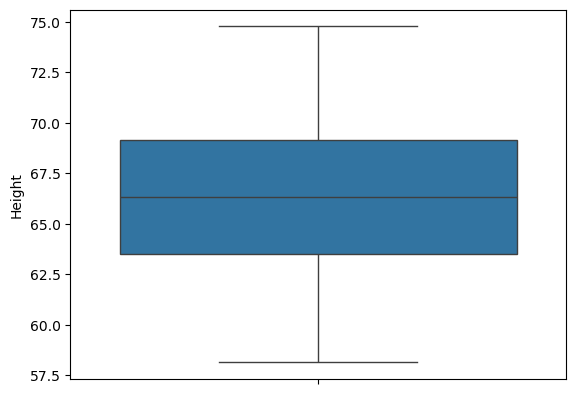

In [60]:
sns.boxplot(data_set["Height"])

## Correction of Datatype

In [61]:
dataset = pd.read_csv("AB_NYC_2019.csv")

In [62]:
dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [64]:
dataset.info() # Gives datatype of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48906 entries, 0 to 48905
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48906 non-null  int64  
 1   name                            48890 non-null  object 
 2   host_id                         48906 non-null  int64  
 3   host_name                       48885 non-null  object 
 4   neighbourhood_group             48906 non-null  object 
 5   neighbourhood                   48906 non-null  object 
 6   latitude                        48906 non-null  float64
 7   longitude                       48906 non-null  float64
 8   room_type                       48906 non-null  object 
 9   price                           48906 non-null  int64  
 10  minimum_nights                  48906 non-null  int64  
 11  number_of_reviews               48906 non-null  int64  
 12  last_review                     

In [65]:
dataset.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.890600e+04,4.890600e+04,48906.000000,48906.000000,48906.000000,48906.000000,48906.000000,38854.000000,48906.000000,48906.000000
mean,1.901287e+07,6.760480e+07,40.728952,-73.952175,152.711324,7.031612,23.300454,1.373151,7.142702,112.782031
std,1.098557e+07,7.860866e+07,0.054529,0.046154,240.128713,20.512489,44.607175,1.680270,32.948926,131.620370
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.464662e+06,7.809567e+06,40.690100,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967545e+07,3.078463e+07,40.723080,-73.955685,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915085e+07,1.074344e+08,40.763120,-73.936283,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [66]:
dataset["id"] = dataset["id"].astype("str")

In [67]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48906 entries, 0 to 48905
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48906 non-null  object 
 1   name                            48890 non-null  object 
 2   host_id                         48906 non-null  int64  
 3   host_name                       48885 non-null  object 
 4   neighbourhood_group             48906 non-null  object 
 5   neighbourhood                   48906 non-null  object 
 6   latitude                        48906 non-null  float64
 7   longitude                       48906 non-null  float64
 8   room_type                       48906 non-null  object 
 9   price                           48906 non-null  int64  
 10  minimum_nights                  48906 non-null  int64  
 11  number_of_reviews               48906 non-null  int64  
 12  last_review                     

In [68]:
dataset["id"].dtype

dtype('O')

In [71]:
dataset["host_id"] = dataset["host_id"].astype("int")

In [72]:
dataset["host_id"].dtype

dtype('int64')

In [73]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48906 entries, 0 to 48905
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48906 non-null  object 
 1   name                            48890 non-null  object 
 2   host_id                         48906 non-null  int64  
 3   host_name                       48885 non-null  object 
 4   neighbourhood_group             48906 non-null  object 
 5   neighbourhood                   48906 non-null  object 
 6   latitude                        48906 non-null  float64
 7   longitude                       48906 non-null  float64
 8   room_type                       48906 non-null  object 
 9   price                           48906 non-null  int64  
 10  minimum_nights                  48906 non-null  int64  
 11  number_of_reviews               48906 non-null  int64  
 12  last_review                     

In [75]:
dataset["last_review"] = pd.to_datetime(dataset["last_review"])

dataset["last_review"].dtype # Converts to datetime format

dtype('<M8[ns]')